In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
from mad.configs import mercury_redstone, mercury_capsule, mercury_atlas
from mad.configs import EARTH_SETTINGS
from mad.objs import Planet, PlanetConfig
from mad.objs import RocketConfig, RocketStage, RocketStageConfig, Rocket, CapsuleConfig, Capsule
from mad.guidances import StraightUp, PitchRollManoeuver, DeployChute, GuidanceStates
from mad.simulation import Simulation
from mad.utils.logger import SourceLogger
from mad.utils.plotters import plot_2D_planet_with_points

logger = SourceLogger()

In [5]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

launchsite_target_distance_km = 1_000
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.random_point_at_surface(name="Launchpad", altitude=10, dims=2)
target = earth.point_at_distance(launchpad, distance_km=launchsite_target_distance_km, name="Target", dims=2)

earth

Planet Earth at [0. 0. 0.]
Mass 5.97e+24 kg, Radius 6371.0 km.
Gravity at surface: -9.82 m/s^2
Orbital velocity: 7909.55 m/s
Escape velocity: 11185.79 m/s

In [8]:

capsule_config = CapsuleConfig(**mercury_capsule, guidance = StraightUp(target=target, planet=earth))
redstone_stages = [RocketStage(RocketStageConfig(**stage_cfg)) for stage_cfg in mercury_redstone]



redstone_cfg = RocketConfig(stages=redstone_stages, 
                          guidance=StraightUp(target=target, planet=earth),
                          payloads=[capsule_config],
                          )
redstone = Rocket(position=launchpad.position.copy(), config=redstone_cfg, name="Redstone")

redstone



Rocket Redstone, active.
Stages: Mercury Redstone.
Available deltaV: 4656.18 m/s.
Guidance: StraightUp.
Payloads: Mercury Capsule.

In [9]:
dt = 0.5
max_time = 2_000.

sim = Simulation(max_time=max_time, dt=dt)
sim.run(
    planet=earth,
    moving_objs=[redstone],
)

df = sim.results


19:15:28 | INFO     | Simulation   | 0.00s - Starting simulation.
19:15:28 | INFO     | Rocket       | 153.00s - Mercury Redstone ran out of propellant at 153.00.
19:15:28 | INFO     | Rocket       | 153.00s - Redstone - Mercury Redstone separated at 153.00.
19:15:28 | INFO     | Rocket       | 153.00s - Redstone entering coast phase at 153.00.
19:15:28 | INFO     | Simulation   | 153.00s - New objects spawned this step: ['Mercury Redstone']
19:15:28 | INFO     | Rocket       | 845.00s - Redstone impacted the ground at 845.00.
19:15:28 | INFO     | Projectile   | 856.00s - Mercury Redstone landed on the ground!
19:15:28 | INFO     | Simulation   | 856.00s - Simulation ended. Took 0.24 s of real time.


In [10]:
df["altitude_km"] = df["position"].apply(lambda pos: (np.linalg.norm(pos) - earth.radius) / 1e3)
df["energy_kJ"] = df["speed"].apply(lambda speed: 0.5 * speed**2 / 1e3)
df["gamma_deg"] = df["gamma"].apply(lambda g: np.degrees(g) if g is not None else None)
df = df.sort_values(by=["name", "time"])

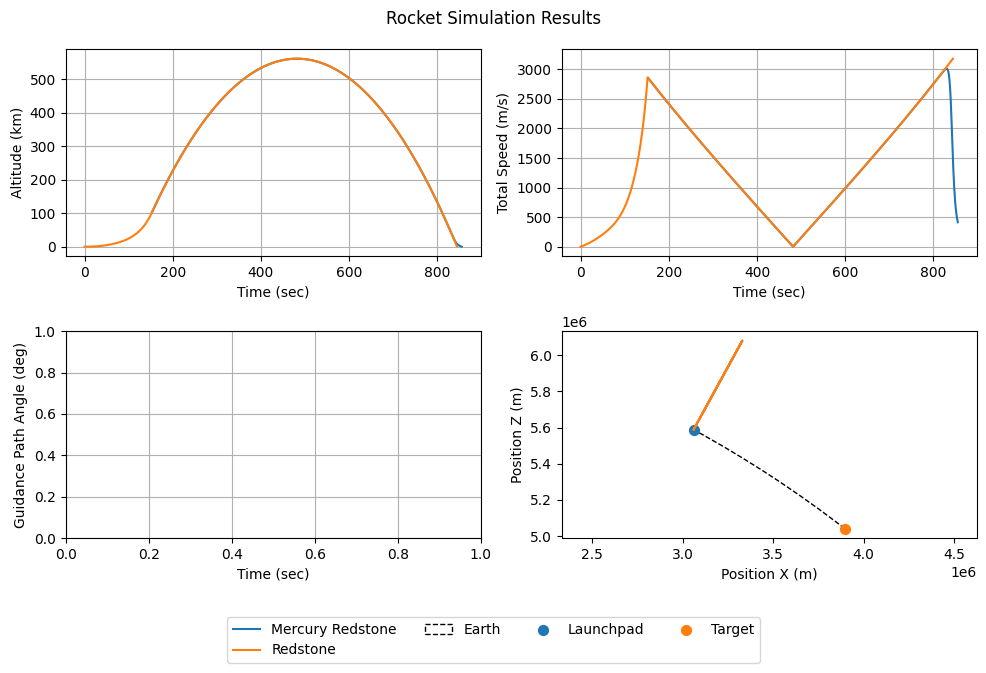

In [11]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 6))
ax = ax.ravel()

sns.lineplot(data=df, x="time", y="altitude_km", hue="name", ax=ax[0])
sns.lineplot(data=df, x="time", y="speed", hue="name", ax=ax[1])
sns.lineplot(data=df, x="time", y="gamma_deg", hue="name", ax=ax[2])
sns.lineplot(data=df, x="posx", y="posz", hue="name", ax=ax[3], sort=False, errorbar=None)

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")

ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Guidance Path Angle (deg)")

plot_2D_planet_with_points(earth, points = [launchpad, target], ax=ax[3], display="arc")
ax[3].set_xlabel("Position X (m)")
ax[3].set_ylabel("Position Z (m)")
ax[3].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()
    handles, labels = a.get_legend_handles_labels()
    a.legend().remove()

fig.suptitle("Rocket Simulation Results")
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(pad=1.2)